### Proyecto final - 4Geeks Academy
Bootcamp Data Science & Machine Learning.

In [4]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.linear_model import Ridge
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

from sklearn.metrics import mean_squared_error, r2_score
from pickle import dump

### Apertura de datasets

El archivo appearence_agrupado, ha sido trabajado en el google colab en el siguiente link:
https://colab.research.google.com/drive/1kkoDlp4htYlhvd1pJ4Mg8GcqiJniWnwx#scrollTo=55sTvyXtUQs0
pues el original tiene una alta cantidad de registros que no permite trabajarlo en codespace por su tamaño.

La descripción del proceso está en el archivo README_proy_final.md

In [5]:
appearence = pd.read_csv("/workspaces/Proy_final_TemporalTransfer/data/appearence_agrupado.csv")
players = pd.read_csv("/workspaces/Proy_final_TemporalTransfer/data/players.csv")
player_valuations = pd.read_csv("/workspaces/Proy_final_TemporalTransfer/data/player_valuations.csv")

ds_players_info= {"Appearence": appearence, "Players":players, "Player Valuations":player_valuations}

for name, dataset in ds_players_info.items():
    print(f"El shape de {name}: {dataset.shape}")

for name, dataset in ds_players_info.items():
    print(f"Las columnas de {name}: {dataset.columns}")

El shape de Appearence: (203718, 12)
El shape de Players: (32480, 23)
El shape de Player Valuations: (494561, 5)
Las columnas de Appearence: Index(['player_id', 'year', 'competition_id', 'club_name', 'player_name',
       'matches_played', 'yellow_cards', 'red_cards', 'goals', 'assists',
       'minutes_played', 'age'],
      dtype='object')
Las columnas de Players: Index(['player_id', 'first_name', 'last_name', 'name', 'last_season',
       'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth',
       'country_of_citizenship', 'date_of_birth', 'sub_position', 'position',
       'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name',
       'image_url', 'url', 'current_club_domestic_competition_id',
       'current_club_name', 'market_value_in_eur',
       'highest_market_value_in_eur'],
      dtype='object')
Las columnas de Player Valuations: Index(['player_id', 'date', 'market_value_in_eur', 'current_club_id',
       'player_club_domestic_competition_id'],
 

Información de Kaggle cómo unir los distintos dataset

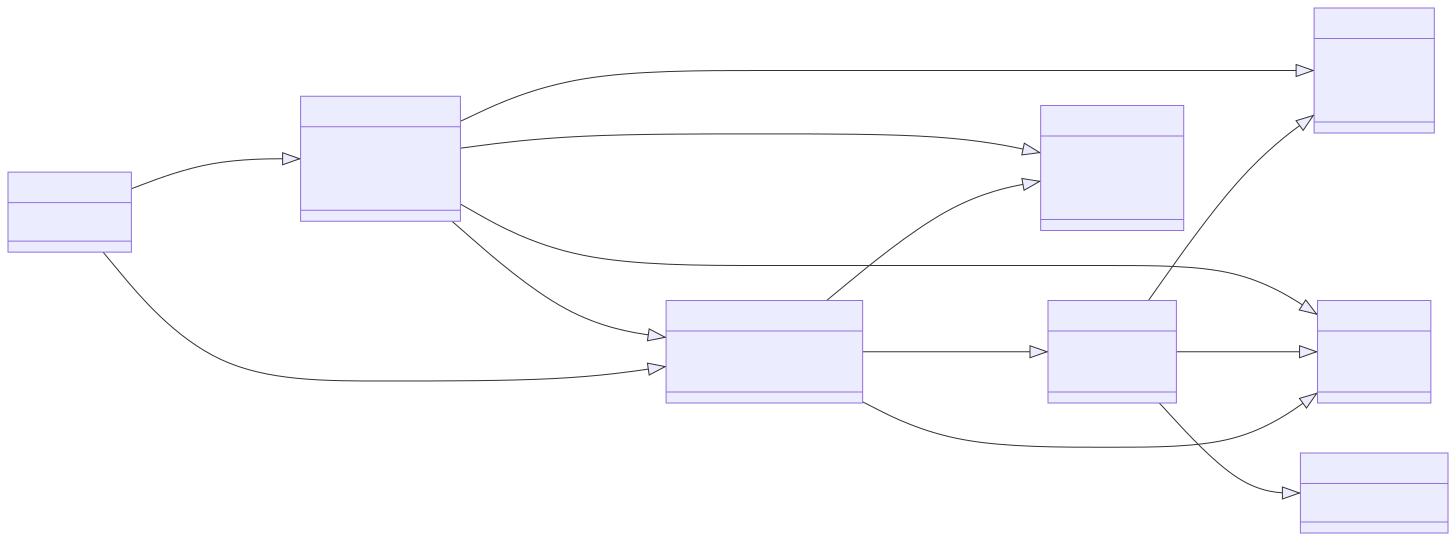

In [4]:
from IPython.display import SVG, display

display(SVG(filename="/workspaces/Proy_final_TemporalTransfer/data/diagram.svg"))

Filtrado de datasets por columnas relevantes:

In [3]:
for name, dataset in ds_players_info.items():
    print(f"Las columnas de {name}: {dataset.columns}")

Las columnas de Appearence: Index(['player_id', 'year', 'competition_id', 'club_name', 'player_name',
       'matches_played', 'yellow_cards', 'red_cards', 'goals', 'assists',
       'minutes_played', 'age'],
      dtype='object')
Las columnas de Players: Index(['player_id', 'first_name', 'last_name', 'name', 'last_season',
       'current_club_id', 'player_code', 'country_of_birth', 'city_of_birth',
       'country_of_citizenship', 'date_of_birth', 'sub_position', 'position',
       'foot', 'height_in_cm', 'contract_expiration_date', 'agent_name',
       'image_url', 'url', 'current_club_domestic_competition_id',
       'current_club_name', 'market_value_in_eur',
       'highest_market_value_in_eur'],
      dtype='object')
Las columnas de Player Valuations: Index(['player_id', 'date', 'market_value_in_eur', 'current_club_id',
       'player_club_domestic_competition_id'],
      dtype='object')


In [7]:
#Edad del jugador con números enteros:
appearence['age'] = appearence['age'].astype(int)

#Filtrado:
player_valuations_filtered=player_valuations.drop(["current_club_id", "player_club_domestic_competition_id"], axis = 1)
players_filtered=players.drop(["first_name", "last_name", "last_season", "current_club_id", "player_code", "contract_expiration_date","agent_name","image_url","url", "current_club_domestic_competition_id","current_club_name","market_value_in_eur"], axis = 1)


Agrupación de los dataset

In [8]:
# 1. Convertir la columna 'date' al formato datetime 
player_valuations_filtered['date'] = pd.to_datetime(player_valuations_filtered['date'])

# 2. Crear una nueva columna que contenga el año del partido
player_valuations_filtered['year'] = player_valuations_filtered['date'].dt.year

# 3. Agrupar por 'player_id' y 'year'
gb_player_val = player_valuations_filtered.groupby(['player_id', 'year']).agg({
    "market_value_in_eur":"mean"
}).reset_index()

# 4. Ver el resultado
print(gb_player_val.shape)
print(gb_player_val.head())

(249891, 3)
   player_id  year  market_value_in_eur
0         10  2004            7000000.0
1         10  2005           12000000.0
2         10  2006           25000000.0
3         10  2007           23000000.0
4         10  2008           20000000.0


Union de dataset

A pesar de de que tenemos información de el valor de venta de los jugadores a partir del año 2004, realizaremos la unión de los dataset priorizando la información de  los partidos realizados con cada jugador (a partir de 2012), porque son caracteristicas relevantes para nuestra predicción.

Para ello usamos la herramienta merge "inner", para no generar datos nulos ni completar con información sesgada en los años 2004 a 2011.

In [9]:
# Merge de appearence y player_valuation:

app_plval_merged = pd.merge(appearence, gb_player_val, on=['player_id', 'year'], how='inner')

# Merge con información de jugadores

df_merge = pd.merge(app_plval_merged, players_filtered, on=['player_id'], how='inner')
df_merge = df_merge.drop(["name"], axis = 1)

print(df_merge.shape)
print(df_merge.head())

(193246, 22)
   player_id  year competition_id                      club_name  \
0         10  2012             EL  Società Sportiva Lazio S.p.A.   
1         10  2012            ELQ  Società Sportiva Lazio S.p.A.   
2         10  2012            IT1  Società Sportiva Lazio S.p.A.   
3         10  2013            CIT  Società Sportiva Lazio S.p.A.   
4         10  2013             EL  Società Sportiva Lazio S.p.A.   

      player_name  matches_played  yellow_cards  red_cards     goals  \
0  Miroslav Klose               2      0.000000        0.0  0.000000   
1  Miroslav Klose               1      1.000000        0.0  1.000000   
2  Miroslav Klose              17      0.294118        0.0  0.588235   
3  Miroslav Klose               2      0.500000        0.0  0.000000   
4  Miroslav Klose               3      0.333333        0.0  0.000000   

    assists  ...  market_value_in_eur  country_of_birth  city_of_birth  \
0  0.000000  ...            6000000.0            Poland          Opole 

In [10]:
df_merge.columns

Index(['player_id', 'year', 'competition_id', 'club_name', 'player_name',
       'matches_played', 'yellow_cards', 'red_cards', 'goals', 'assists',
       'minutes_played', 'age', 'market_value_in_eur', 'country_of_birth',
       'city_of_birth', 'country_of_citizenship', 'date_of_birth',
       'sub_position', 'position', 'foot', 'height_in_cm',
       'highest_market_value_in_eur'],
      dtype='object')

In [11]:
duplicados = df_merge.duplicated()
num_duplicados = duplicados.sum()
print(f"La cantidad de duplicados en nuestro dataset: {num_duplicados}")
df_merge.info()

La cantidad de duplicados en nuestro dataset: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193246 entries, 0 to 193245
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   player_id                    193246 non-null  int64  
 1   year                         193246 non-null  int64  
 2   competition_id               193246 non-null  object 
 3   club_name                    193246 non-null  object 
 4   player_name                  193246 non-null  object 
 5   matches_played               193246 non-null  int64  
 6   yellow_cards                 193246 non-null  float64
 7   red_cards                    193246 non-null  float64
 8   goals                        193246 non-null  float64
 9   assists                      193246 non-null  float64
 10  minutes_played               193246 non-null  float64
 11  age                          193246 non-null  int64  
 12  market_val

uestro dataset cuenta con la información de distintos jugadores, separadas por año y juntando la información de distintos partidos separada por competiciones, con la respectiva valuación en euros de cada jugador en ese momento.

- Contamos con 196.238 y 22 atributos.
- No tenemos datos duplicados.
- Contamos con algunos valores nulos en las variables "country_of_birth", "city_of_birth", "country_of_citizenship", "sub_position", "foot", "height_in_cm".

### Análisis Exploratorio de Datos

Carácterísticas relevantes:

- Nustra variable a predecir será "market_value_in_eur", que es un valor numérico.
- Nos quedaremos con las siguientes características para predecir nuestro objetivo:
    - competition_id (cat): el tipo de competición donde se jugó ese partido.
    - club_name (cat): El nombre del club en el cual pertenece el jugador ese año.
    - matches_played (num): cantidad de partidos jugados en un año, separados por competencia.
    - yellow_cards (num): promedio de tarjetas amarillas recibidas en un año, separados por competencia.
    - red_cards (num): promedio de tarjetas rojas recibidas en un año, separados por competencia.
    - goals (num): promedio de cantidas de goles hechos en un año, separados por competencia.
    - assists (num): promedio de cantidas de asistencias hechos en un año, separados por competencia.
    - minutes_played (num): promedio de minutos jugados en un año, separados por competencia.
    - age (num): edad del jugador en ese año.
    - country_of_birth (cat): país de nacimiento del jugador.
    - city_of_birth (cat): ciudad de nacimiento del jugador.
    - position (cat): posición general del jugador.
    - sub_position (cat): posición específica del jugador.
    - foot (cat): pie hábil del jugador.
    - height_in_cm (num): altura del jugador.
    - highest_market_value_in_eur (num): mayor cotización del jugador hasta el momento.
    - market_value_in_eur (num): La cotización del jugador por año. (Nustra variable objetivo)

Eliminamos variables no relevantes:
- player_id, player_name: por ser valores irrelevantes en nuestra predicción.
- year: se utilizó para las agrupaciones de los partidos y valuaciones por año.
- country_of_citizenship: nos quedamos con el país y ciudad de nacimiento.
- date_of_birth: se utilizó para calcular la edad de los jugadores en los recpectivos años.

In [12]:
df_filtrado=df_merge.drop(['player_id', 'year', 'player_name','country_of_citizenship', 'date_of_birth'], axis = 1)
df_filtrado.shape

(193246, 17)

Análisis de valores nulos

In [13]:
print(df_filtrado.isnull().sum().sort_values(ascending=False))

country_of_birth               6091
city_of_birth                  3415
foot                           3141
height_in_cm                   2344
sub_position                    211
competition_id                    0
club_name                         0
yellow_cards                      0
matches_played                    0
age                               0
minutes_played                    0
assists                           0
goals                             0
red_cards                         0
market_value_in_eur               0
position                          0
highest_market_value_in_eur       0
dtype: int64


Debido a la gran cantidad de datos que tenemos y que el porcentaje de datos nulos es bajo, eliminaremos las dichas filas para continuar con nuestro análisis, para no ensuciar el dataset.

In [14]:
df_sin_nulos = df_filtrado.dropna()
print(df_sin_nulos.shape)
df_sin_nulos.isnull().sum().sort_values(ascending=False)
df=df_sin_nulos

(183607, 17)


Eliminando los valores nulos, tenemos un total de 183.607 datos y 17 variables.

Guardado de dataframe sin valores nulos

In [15]:
df.to_csv('/workspaces/Proy_final_TemporalTransfer/data/df_final_sin_nulos.csv', index=False)

### Análisis univarido

In [16]:
# Apertura de dataset sin nulos

df=pd.read_csv("/workspaces/Proy_final_TemporalTransfer/data/df_final_sin_nulos.csv")

Variables Numéricas

In [18]:
numerical_columns = df.select_dtypes(include=['number']).columns

df.describe()

,matches_played,yellow_cards,red_cards,goals,assists,minutes_played,age,market_value_in_eur,height_in_cm,highest_market_value_in_eur
count,183607.000000,183607.000000,183607.000000,183607.000000,183607.000000,183607.000000,183607.000000,1.836070e+05,183607.000000,1.836070e+05
mean,8.516478,0.139773,0.004035,0.088073,0.069183,65.155403,25.532039,5.721055e+06,182.203707,1.139983e+07
std,8.814760,0.220874,0.040446,0.207374,0.169358,26.310151,4.305076,1.164345e+07,6.656681,1.889193e+07
min,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,15.000000,1.000000e+04,19.000000,1.000000e+04
25%,2.000000,0.000000,0.000000,0.000000,0.000000,47.200000,22.000000,5.500000e+05,178.000000,1.250000e+06
50%,5.000000,0.000000,0.000000,0.000000,0.000000,72.200000,25.000000,1.625000e+06,182.000000,4.000000e+06
75%,13.000000,0.200000,0.000000,0.083333,0.068966,88.500000,29.000000,5.250000e+06,187.000000,1.300000e+07
max,43.000000,2.000000,1.000000,4.000000,4.000000,120.000000,43.000000,2.000000e+08,207.000000,2.000000e+08


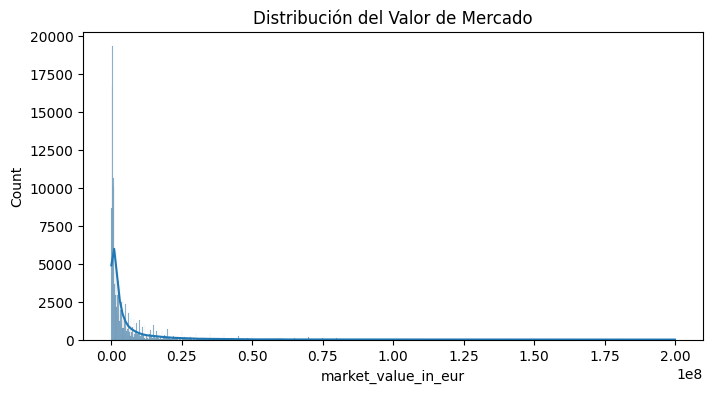

In [22]:
plt.figure(figsize=(8,4))
sns.histplot(df["market_value_in_eur"], kde=True)
plt.title("Distribución del Valor de Mercado")
plt.show()

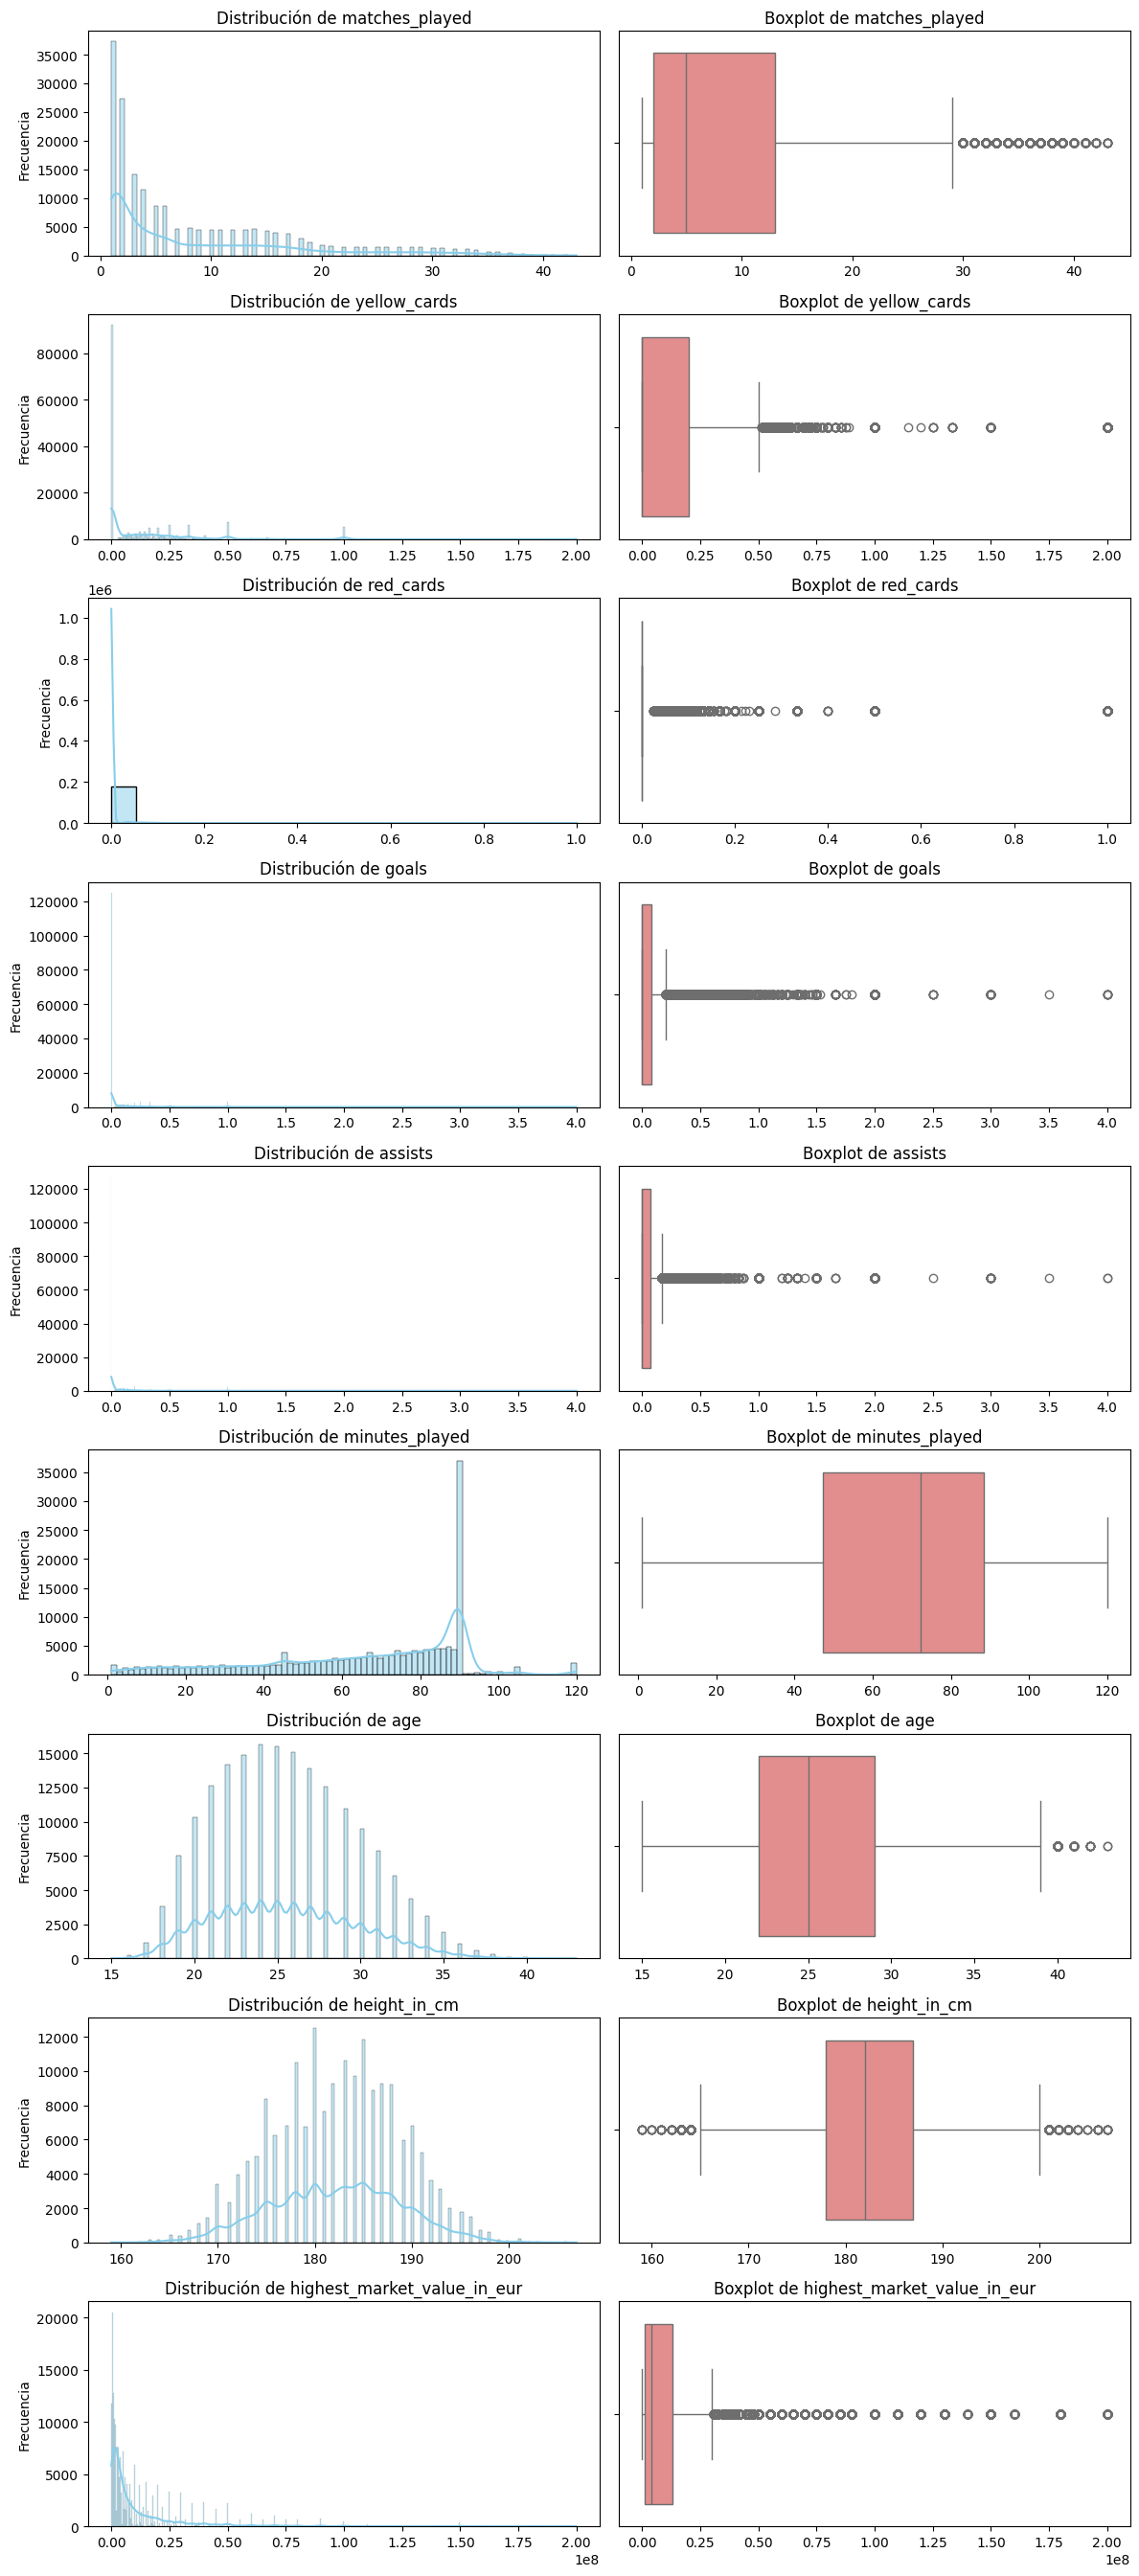

In [24]:
numerical_features = [col for col in numerical_columns 
                      if col != "market_value_in_eur"]

# Crear una figura con subplots
fig, axes = plt.subplots(len(numerical_features), 2, figsize=(12, len(numerical_features) * 3), 
                         gridspec_kw={'height_ratios': [1] * len(numerical_features)})

# Iterar por cada variable y generar gráficos
for i, var in enumerate(numerical_features):
    # Histograma
    sns.histplot(ax=axes[i, 0], data=df, x=var, kde=True, color='skyblue')
    axes[i, 0].set(title=f"Distribución de {var}", xlabel=None, ylabel="Frecuencia")
    
    # Boxplot
    sns.boxplot(ax=axes[i, 1], data=df, x=var, color='lightcoral')
    axes[i, 1].set(title=f"Boxplot de {var}", xlabel=None, ylabel=None)

# Ajustar diseño
plt.tight_layout()
plt.show()

Podemos observar que en todas las variables, los outliers no son datos erroneos, entran en los parámetros esperados (excepto la altura menor a 150 cm).

In [20]:
df[df["height_in_cm"] < 150]

,competition_id,club_name,matches_played,yellow_cards,red_cards,goals,assists,minutes_played,age,market_value_in_eur,country_of_birth,city_of_birth,sub_position,position,foot,height_in_cm,highest_market_value_in_eur
171398,SC1,Motherwell Football Club,10,0.2,0.0,0.0,0.0,62.6,26,250000.0,England,Reading,Left-Back,Defender,left,19.0,350000.0


In [21]:
df.loc[df['height_in_cm'] == 19, 'height_in_cm'] = 190